In [1]:
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import pandas as pd
import seaborn
import math
%matplotlib inline

# Гречишкин Денис ПМ-31

# Лабораторная работа №4

## Часть 4.4

## Пример 1

Генерирование выборки распределения хи-квадрат и поиск точечных оценок числовых характеристик распределения 

In [2]:
n = 500
x_n = np.random.chisquare(4, n)
sts.describe(x_n, ddof = 0)

DescribeResult(nobs=500, minmax=(0.11165139354007528, 20.286812125391656), mean=4.174725089283863, variance=8.686729297051919, skewness=1.5297324849797196, kurtosis=3.4794898756030337)

построение гистограммы и боксплота

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:ylabel='Count'>

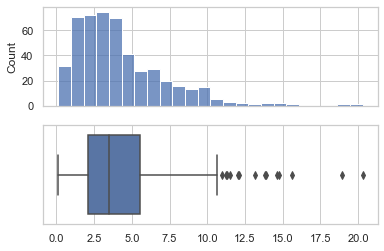

In [3]:
seaborn.set(style = 'whitegrid')
f, (ax_hist2, ax_box2) = plt.subplots(2, sharex = True)

seaborn.boxplot(x_n, ax = ax_box2, orient = 'h')
seaborn.histplot(x_n, ax = ax_hist2)

## Пример 2

Иллюстрация состоятельности выборочного центрального момента четвертого порядка

теоретическое значение четвертого центрального момента 3888.0


Text(0.5, 1.0, 'последовательность выборочных моментов')

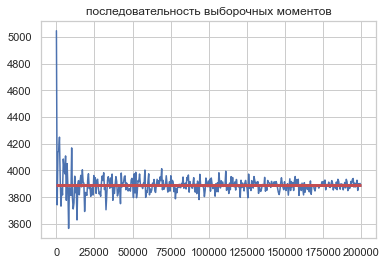

In [4]:
m = 2
sigma = 6
nn = np.arange(100, 200000, 500)
i = 0
m4_v_sost = np.full(len(nn), 1.)
for n in nn:
    xx = np.random.normal(loc = m, scale = sigma, size = n)
    m4_v_sost[i] = sts.moment(xx, moment = 4)
    i +=1
plt.plot(nn, m4_v_sost)
m4 = sts.norm(0, sigma).moment(4)
print('теоретическое значение четвертого центрального момента', m4)
plt.hlines(m4, nn[0], nn[len(nn) - 1], color  = 'r', lw = 3)
plt.grid(True)
plt.title('последовательность выборочных моментов')

ВЫВОД: при увеличении объема выборки оценка становится "точнее"

Исследование на смещенность выборочного четвертого центрального момента

In [5]:
N = 10000
n_m4 = 1000
m4_v_sm = np.full(N, 1.)
for k in np.arange(0, N):
    x_k = np.random.normal(loc = m, scale = sigma, size = n_m4)
    m4_v_sm[k] = sts.moment(x_k, moment = 4)
#по сформированной выборке оценим мат. ожидание выборочного четвертого центрального момента
m_m4_v_sm = np.mean(m4_v_sm)
print('теор. зн-е 4-го ц. момента', m4)
print('ср. зн-е 4-го ц. момента', m_m4_v_sm)

теор. зн-е 4-го ц. момента 3888.0
ср. зн-е 4-го ц. момента 3880.8300108253225


$\newline$

## Часть 4.5 (Задания для самостоятельного выполнения)

## Задание 1

Пусть случайная величина X имеет равномерное распределение на отрезке[0,1] и $X_1, X_2 , ...,X_n$ – случайная выборка объема 
n генеральной совокупности X. Для математического ожидания генеральной совокупности рассмотрим две оценки: выборочное среднее 
$\overline X = \frac{\sum_{k = 1} ^{n} X_k}{n}$ и случайную величину $\hat m = \frac{X^{(1)} + X^{(2)}}{2}$ где $X^{(1)}, X^{(2)}$ - наибольший и наименьший элемент выборки соответственно. Проведите вычислительные эксперименты, позволяющие визуализировать и сопоставить свойства этих оценок, результаты проанализируйте, сформулируйте выводы. 
1) Путем компьютерного моделирования получите выборки различного объема n (рассмотрите последовательность n от 50 до 10 000 с 
некоторым шагом). Для каждой выборки вычислите значения обеих 
оценок. Визуализируйте результаты, построив графики последовательностей реализаций значений оценок. Опираясь на полученные результаты, исследуйте вопрос о состоятельности оценок $\overline X$ и $\hat m$
2) Зафиксируйте достаточно большое значение n (например, 10 000 ). Путем компьютерного моделирования сгенерируйте N выборок случайных величин
$\overline X = \frac{\sum_{k = 1} ^{n} X_k}{n}$ и $\hat m = \frac{X^{(1)} + X^{(2)}}{2}$. Опираясь на теорему Чебышёва, исследуйте вопрос о несмещенности оценок $\overline X$ и $\hat m$  (например, для $\overline X$ рассуждаем так: по теореме Чебышёва среднее арифметическое выборочных значений случайной величины $\overline X$ сходится по вероятности к математическому ожиданию $\overline X$, и, следовательно, при больших N среднее арифметическое выборочных значений случайной величины $\overline X$ с вероятностью, близкой к единице, будет «очень 
близко» к $M[\overline X]$, и, значит, при проверке равенства $M[\overline X] = M[X]$ можно заменить $M[\overline X]$ средним арифметическим выборочных значений случайной величины $\overline X$).
3) Зафиксируйте достаточно большое значение n. Путем компьютерного моделирования сгенерируйте выборки объема N случайных 
величин – оценок $\overline X = \frac{\sum_{k = 1} ^{n} X_k}{n}$ и $\hat m = \frac{X^{(1)} + X^{(2)}}{2}$ (N должно быть 
велико) и визуализируйте их двумя способами: (1) с помощью боксплотов; (2) с помощью гистограммы. Опираясь на полученные результаты, 
исследуйте вопрос о сравнительной эффективности оценок  $\overline X$ и $\hat m$.

## Решение

## пункт 1: 
Для проверки состоятельности, сформируем массив размеров выборок, для каждого элемента из данного массива составим выборку в соответствии с равномерным распределением, для каждой из выборок посчитаем обе оценки и построим графики зависимостей значений оценок от размера выборки

Text(0.5, 1.0, 'графики зависимости выборочных средних и m с крышечкой от размера выборки')

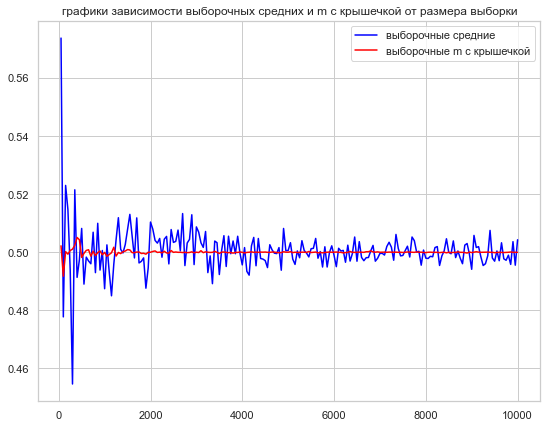

In [6]:
sizes = np.arange(50, 10001, 50)
Sel_Srs = []
Sel_Ms = []
for size in sizes:
    Selection = np.random.uniform(0, 1, size)
    Sel_Sr = sum(Selection)/size
    Sel_Srs.append(Sel_Sr)
    Sel_m = (max(Selection) + min(Selection))/2
    Sel_Ms.append(Sel_m)
plt.figure(figsize = (9, 7))
plt.plot(sizes, Sel_Srs, color = 'blue', label = 'выборочные средние')
plt.plot(sizes, Sel_Ms, color = 'red', label = 'выборочные m с крышечкой')
plt.grid(True)
plt.legend()
plt.title('графики зависимости выборочных средних и m с крышечкой от размера выборки')

Из графиков можно сделать вывод, что обе оценки являются состоятельными

## пункт 2: 
сформируем 50 выборок объема 1000. Для каждой из выборки найдем значения выборок и сформируем массивы из значений оценок для каждой из 50 выборок. Для того чтобы продемонстрировать, является ли каждая из оценок смещенной или несмещенной, построим график истинного значения мат ожидания отрезком от 99 до 101 и расставим значения оценок на отметке 100.

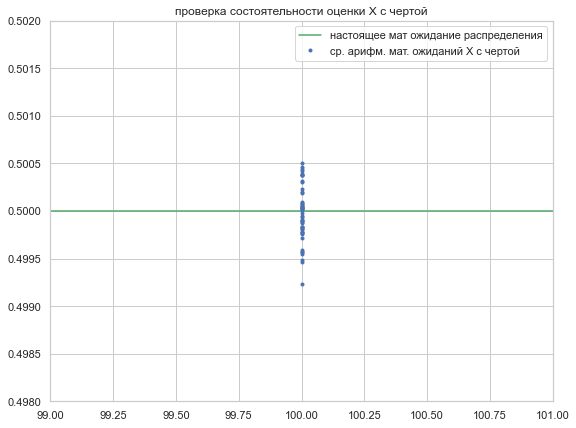

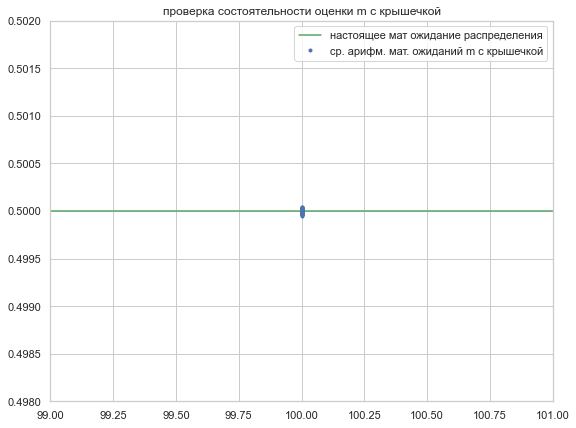

In [7]:
n = 1000
N = 50
sr_ars1 = []
sr_ars2 = []
for i in range(N):
    selection_srs = []
    selection_ms = []
    for j in range(n):
        Sel = np.random.uniform(0, 1, n)
        Sel_Sr = sum(Sel)/n
        selection_srs.append(Sel_Sr)
        Sel_m = (max(Sel) + min(Sel))/2
        selection_ms.append(Sel_m)
    sr_ars1.append(sum(selection_srs) / n)
    sr_ars2.append(sum(selection_ms) / n)

M_X = (sts.uniform(0, 1)).mean()    

plt.figure(figsize = (9, 7))
x = np.linspace(99, 101, 100)
m_X = 0.5*x**0
plt.plot(x, m_X, '-g', label = 'настоящее мат ожидание распределения')
plt.plot(100, sr_ars1[0], '.b', label = 'ср. арифм. мат. ожиданий X с чертой')
for el in sr_ars1[:len(sr_ars1) - 1]:
    plt.plot(100, el, '.b')
plt.grid(True)
plt.axis([99, 101, 0.498, 0.502])
plt.title('проверка состоятельности оценки X с чертой')
plt.legend()

plt.figure(figsize = (9, 7))
x = np.linspace(99, 101, 100)
m_X = 0.5*x**0
plt.plot(x, m_X, '-g', label = 'настоящее мат ожидание распределения')
plt.plot(100, sr_ars2[0], '.b', label = 'ср. арифм. мат. ожиданий m с крышечкой')
for el in sr_ars2[:len(sr_ars2) - 1]:
    plt.plot(100, el, '.b')
plt.grid(True)
plt.axis([99, 101, 0.498, 0.502])
plt.title('проверка состоятельности оценки m с крышечкой')
plt.legend()

Из графиков можно сделать вывод, что обе оценки являются несмещенными

## пункт 3: 
Сгенерируем 5000 выборок объема 10000, для каждой из них найдем хначения оценок, и будем добавлять их в массивы из значений соответствующих оценок selection_srs и selection_ms. Для того чтобы построить гистограммы и боксплоты, воспользуемся функцией, использованной в примере 1. 

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'гистограмма и боксплот для оценки m с крышечкой')

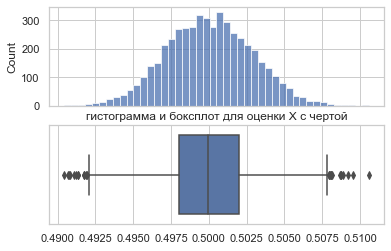

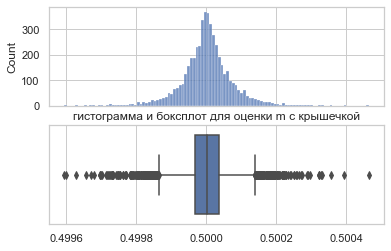

In [8]:
n = 10000
N = 5000
selection_srs = []
selection_ms = []
for i in range(N):
    Sel = np.random.uniform(0, 1, n)
    Sel_Sr = sum(Sel)/n
    selection_srs.append(Sel_Sr)
    Sel_m = (max(Sel) + min(Sel))/2
    selection_ms.append(Sel_m)

seaborn.set(style = 'whitegrid')
f1, (ax_hist21, ax_box21) = plt.subplots(2, sharex = True)
seaborn.boxplot(selection_srs, ax = ax_box21, orient = 'h')
seaborn.histplot(selection_srs, ax = ax_hist21)
plt.title('гистограмма и боксплот для оценки X с чертой')

f2, (ax_hist22, ax_box22) = plt.subplots(2, sharex = True)
seaborn.boxplot(selection_ms, ax = ax_box22, orient = 'h')
seaborn.histplot(selection_ms, ax = ax_hist22)
plt.title('гистограмма и боксплот для оценки m с крышечкой')

Из гистограмм видно, что оценка m с крышечкой является более эффективной чем оценка X с чертой

$\newline$

## Задание 2: Теоретически проверьте выводы о свойствах оценок $\overline X$ и $\hat m$, к которым вы пришли в ходе выполнения задания 1.

## Решение: для начала рассмотрим свойства оценки $\overline X$.
1. По теореме о предельных значениях выборочных начальных моментов, можно сказать что эта оценка - состоятельна.$\newline$
2. Докажем, что эта оценка - несмещённая: $$M[m^*(X_1, ..., X_n)] = M[\frac{1}{n} \sum_{k = 1}^{n} X_k] = \frac{1}{n} \cdot \sum_{k = 1}^{n} M[X_k] = \frac{1}{n} \cdot \sum_{k = 1}^{n} m = m$$
3. Поскольку в задании рассматривается не нормально распределенная случайная величина; а равномерно распределённая, то нельзя сказать что эта оценка наиболее эффективна, т.е найдется оценка более эффективная чем $\overline X$.

Теперь рассмотрим свойства оценки $\hat m$.
1. Докажем что эта оценка - несмещенная, для этого найдем мат ожидание максимального и минимального элементов выборки:
$$M[X^{(1)}] = \int_{-\infty}^{\infty}x\cdot f_{X^{(1)}(x)}dx = 0 + \int_{0}^{1}x\cdot n(1 - x)^{n - 1}dx + 0 = \int_{0}^{1}x\cdot n(1 - x)^{n - 1}dx = \int_{0}^{1} -\frac{x\cdot n(1 - x)^{n}}{x - 1}dx = -n\int_{0}^{1} \frac{x\cdot (1 - x)^{n - 1}}{x - 1} + (1 - x)^n dx = n \cdot (\int_{0}^{1} \frac{x\cdot (1 - x)^{n}}{1 - x}dx + \int_{0}^{1} (1 - x)^n d(1 - x)) = \frac{1}{n + 1}$$

$$M[X^{(2)}] = \int_{-\infty}^{\infty}x\cdot f_{X^{(2)}(x)}dx = 0 + \int_{0}^{1}n\cdot x^{n}dx + 0 = \frac{n}{n + 1}$$
тогда получаем:
$$M[\hat m] = M[\frac{X^{(1)} + X^{(n)}}{2}] = \frac{M[X^{(1)}] + M[X^{(n)}]}{2} = \frac{\frac{1}{n + 1} + \frac{n}{n + 1}}{2} = \frac{1}{2} = m$$

перед тем как доказывать состоятельность оценки, найдем дисперсию минимального и максимального элемента выборки:

$$D[X^{(1)}] = \int_{-\infty}^{\infty}x^2\cdot f_{X^{(1)}(x)}dx - \frac{1}{(n + 1)^2} =\int_{0}^{1} x^2 \cdot n(1 - x)^{n - 1}dx - \frac{1}{(n + 1)^2}=\int_{0}^{1}(x^2 - 2x + 1 + 2x - 1)n(1 - x)^{n - 1}dx - \frac{1}{(n + 1)^2}=\int_{0}^{1}((1 - x)^2 + 2(x - 1) + 1)n(1 - x)^{n - 1}dx - \frac{1}{(n + 1)^2}=-\int_{0}^{1}n(1 - x)^{n + 1}d(1 - x) + 2\int_{0}^{1}n(1 - x)^{n}d(1 - x)-\int_{0}^{1}n(1 - x)^{n - 1}d(1 - x)-\frac{1}{(n + 1)^2}=\frac{n}{(n + 2)(n + 1)^2}$$

$$D[X^{(2)}] = \int_{-\infty}^{\infty}x^2\cdot f_{X^{(2)}(x)}dx - \frac{n}{(n + 1)^2} = \int_{0}^{1}n \cdot x^2 \cdot x^{n - 1}dx - \frac{n}{(n + 1)^2} = \int_{0}^{1}n \cdot x^2 \cdot x^{n - 1}dx - \frac{n}{(n + 1)^2} = \int_{0}^{1}n \cdot x^{n + 1}dx - \frac{n}{(n + 1)^2} = \frac{n}{(n + 1)^2\cdot(n + 2)}$$

2. Докажем что эта оценка - состоятельная: во-первых, она несмещенная(доказано ранее). Во-вторых, т.к максимальный элемент выборки не зависит от минимального, то:
$$D[\hat m] = D[\frac{X^{(1)} + X^{(n)}}{2}] = \frac{D[X^{(1)}] + D[X^{(n)}]}{4} = \frac{\frac{n}{(n + 1)^2 \cdot (n + 2)} + \frac{n}{(n + 1)^2 \cdot (n + 2)}}{4} = \frac{n}{2\cdot(n + 1)^2\cdot(n + 2)} = O(\frac{1}{n^2}) \newline D[\hat m] \rightarrow 0 \newline$$ при $$n \rightarrow \infty$$ 

То есть получаем что по достаточному условию состоятельности оценка $\hat m$ состоятельна. $\newline$
3. Т.к $D[\overline X] = \frac{\sigma}{n} > D[\hat m]$, то оценка $\hat m$ более эффктивна чем $D[\overline X]$.

$\newline$

## Задание 3: Проводятся последовательные испытания по схеме Бернулли с вероятностью успеха 0,25. Случайная величина X – длина появляющихся серий («успехов» или «неудач»), случайная величина Y – длина первой серий (число «успехов» до первой неудачи или число «неудач» до первого «успеха»). Используя метод статистических испытаний, оцените математическое ожидание, медиану, дисперсию, среднее квадратичное отклонение случайных величин X и Y .

## Решение: Сформируем выборки случайных величин X и Y используя выборку испытаний, проводимых по схеме Бернулли. Будем использовать следующие оценки: 
1. Оценка мат ожидания: $\overline X = \frac{\sum_{k = 1} ^{n} X_k}{n}$
2. Оценка дисперсии: $S_X^2 = \frac{1}{n - 1} \sum_{k = 1} ^{n} (X_k - \overline X)^2$
3. Оценка СКО: $S_X = \sqrt{S_X^2}$
4. Медиана - число, делящее отсортированную выборку пополам (в случае четного числа элементов берется среднее арифметическое двух элементов, стоящих посередине)

In [9]:
X_SEL = []
Y_SEL = []
size = 1000

selection = np.random.binomial(1, 0.25, size)
current_digit = selection[0]
c = 1

for digit in selection[1:]:
    if digit == current_digit:
        c += 1
    else:
        X_SEL.append(c)
        current_digit = digit
        c = 1
X_SEL.append(c)

for i in range(size):
    selection1 = np.random.binomial(1, 0.25, size)
    c1 = 1
    while (selection1[c1] == selection1[0]):
        c1+=1
    Y_SEL.append(c1)
    
    
m_est = sum(X_SEL)/len(X_SEL)
d_est = 0
for i in range(len(X_SEL)):
    d_est += (X_SEL[i] - m_est)**2
d_est /= (len(X_SEL)- 1)
sigma_est = np.sqrt(d_est)
X_SEL.sort()
med_est = 0
if len(X_SEL) % 2 == 0:
    med_est = (X_SEL[(len(X_SEL)//2) - 2] + X_SEL[len(X_SEL)//2])/2
else:
    med_est = X_SEL[math.floor(len(X_SEL)/2)]
print('ОЦЕНКИ СЛУЧАЙНОЙ ВЕЛИЧИНЫ X:\n')
print('мат ожидания:', m_est)
print('дисперсии:', d_est)
print('СКО:', sigma_est)
print('медианы:', med_est, '\n \n')


m_est1 = sum(Y_SEL)/len(Y_SEL)
d_est1 = 0
for i in range(len(Y_SEL)):
    d_est1 += (Y_SEL[i] - m_est1)**2
d_est1 /= (len(Y_SEL) - 1)
sigma_est1 = np.sqrt(d_est1)
Y_SEL.sort()
med_est1 = 0
if len(Y_SEL) % 2 == 0:
    med_est1 = (Y_SEL[(len(X_SEL)//2) - 2] + Y_SEL[len(X_SEL)//2])/2
else:
    med_est1 = Y_SEL[math.floor(len(Y_SEL)/2)]
print('ОЦЕНКИ СЛУЧАЙНОЙ ВЕЛИЧИНЫ Y:\n')
print('мат ожидания:', m_est1)
print('дисперсии:', d_est1)
print('СКО:', sigma_est1)
print('медианы:', med_est1)

ОЦЕНКИ СЛУЧАЙНОЙ ВЕЛИЧИНЫ X:

мат ожидания: 2.7472527472527473
дисперсии: 8.205915296824418
СКО: 2.8645968820803422
медианы: 2.0 
 

ОЦЕНКИ СЛУЧАЙНОЙ ВЕЛИЧИНЫ Y:

мат ожидания: 3.416
дисперсии: 10.667611611611646
СКО: 3.2661309850665274
медианы: 1.0


$\newline$

## Задание 4, вариант 1: На окружности радиуса 8 находится точка. В последовательные моменты времени i (i = 1,2,3,...) точка передвигается по 
окружности (в одну и ту же сторону) на случайное расстояние $X_i$, распределенное по показательному закону с параметром 0,2. Случайная 
величина $Y$ – номер того шага, на котором точка пересечет свою исходную позицию. Методом статистических испытаний оцените математическое ожидание, медиану и дисперсию случайной величины $Y$, а также получите оценки начальных и центральных моментов третьего и четвертого порядков

## Решение: проведем 1000 сдвигов по окружности, составим выборку случайной величины Y и, используя её, найдем оценки параметров. Формулы будем использовать те же что и в 3-м номере + формулы оценок моментов ниже: 
1. Оценка начального момента k-го порядка: $\alpha_k = \frac{\sum_{i = 1} ^{n} X_i^k}{n}$
2. Оценка центрального момента k-го порядка: $\mu_k = \frac{\sum_{i = 1} ^{n} (X_i - \overline X)^k}{n - 1}$

In [220]:
R = 8
Lambda = 0.2
Size = 10000
Y_Selection = []
for i in range(Size):
    c1 = 0#номера шагов
    c2 = 0#длины шагов
    while (c2 < 2*np.pi*R):
        c2 += np.random.exponential(1/Lambda)
        c1 += 1
    Y_Selection.append(c1)
            
m_est1 = sum(Y_Selection)/len(Y_Selection)

nach_mom_est3 = 0
nach_mom_est4 = 0
for i in range(len(Y_Selection)):
    nach_mom_est3 += (Y_Selection[i])**3
    nach_mom_est4 += (Y_Selection[i])**4
nach_mom_est3 /= len(Y_Selection)
nach_mom_est4 /= len(Y_Selection)

d_est1 = 0
centr_mom_est3 = 0
centr_mom_est4 = 0
for i in range(len(Y_Selection)):
    d_est1 += (Y_Selection[i] - m_est1)**2
    centr_mom_est3 += (Y_Selection[i] - m_est1)**3
    centr_mom_est4 += (Y_Selection[i] - m_est1)**4
d_est1 /= (len(Y_Selection) - 1)
centr_mom_est3 /= len(Y_Selection)
centr_mom_est4 /= len(Y_Selection)

sigma_est1 = np.sqrt(d_est1)
med_est1 = 0
if len(Y_Selection) % 2 == 0:
    med_est1 = (Y_Selection[(len(Y_Selection)//2) - 2] + Y_Selection[len(Y_Selection)//2])/2
else:
    med_est1 = Y_Selection[math.floor(len(Y_Selection)/2)]

print('ОЦЕНКИ СЛУЧАЙНОЙ ВЕЛИЧИНЫ Y:\n')
print('мат ожидания:', m_est1)
print('дисперсии:', d_est1)
print('СКО:', sigma_est1)
print('медианы:', med_est1)
print('начального момента 3-го порядка', nach_mom_est3)
print('начального момента 4-го порядка', nach_mom_est4)
print('центрального момента 3-го порядка', centr_mom_est3)
print('центрального момента 4-го порядка', centr_mom_est4)

ОЦЕНКИ СЛУЧАЙНОЙ ВЕЛИЧИНЫ Y:

мат ожидания: 11.0365
дисперсии: 10.092577007700841
СКО: 3.176881648362249
медианы: 10.5
начального момента 3-го порядка 1688.8423
начального момента 4-го порядка 22982.6979
центрального момента 3-го порядка 10.422024704249546
центрального момента 4-го порядка 311.1318156714867
